In [42]:
from datetime import datetime, timedelta
import uo_pyfetch
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pickle
from datetime import datetime, timedelta
from IPython.display import HTML



In [43]:
bbox = [-1.652756, 54.973377, -1.620483, 54.983721]

In [44]:
variables = uo_pyfetch.get_variables()
print("Available variables:")
for v in variables["Variables"][:1000]:
    print(f" - {v['Name']} ({v.get('Units', 'no units')})")

Available variables:
 - allpollu (%)
 - Ammonia (?)
 - Average Speed (KmPH)
 - Battery (V)
 - Brood (Celsius)
 - Bus Count (Vehicles)
 - Bus Count East (Vehicles)
 - Bus Count West (Vehicles)
 - Car Count (Vehicles)
 - Cars (Cars)
 - CO (ugm -3)
 - CO2 (ppm)
 - CO2 High Range (ppm)
 - CO2 Low Range (ppm)
 - Congestion (%)
 - Cycle Count (Vehicles)
 - Daily Accumulation Rainfall (mm)
 - Depth (m)
 - Dew Point (Celsius)
 - Dissolved Oxygen (mg/l)
 - Dissolved Oxygen Percentage (%)
 - Dust (?)
 - East-West Horizontal Displacement (m)
 - Filter (%)
 - Fluorescent Dissolved Organic Matter (QSU)
 - Hive Activity (-)
 - Humidity (%)
 - Internal Humidity (%)
 - Internal Temperature (Celsius)
 - Journey Time (seconds)
 - Luminosity (Lux)
 - Max Sound (db)
 - Max Temperature  (Celsius)
 - Max Wind Speed (m/s)
 - Mean Fanning (-)
 - Mean Flight Noise (-)
 - Moisture (%)
 - Motorcycle Count (Vehicles)
 - NH4+N (mg/l)
 - NO (ugm -3)
 - NO2 (ugm -3)
 - NO2 Concentration (ugm -3)
 - NO3-N (mg/l)
 - N

In [45]:
themes = uo_pyfetch.get_themes()
print("\nAvailable themes:")
for t in themes["Themes"]:
    print(f" - {t['Name']}")


Available themes:
 - Sewage
 - Sensor Metrics
 - Electrical
 - Seismic
 - Water Quality
 - Traffic
 - Air Quality
 - Water Level
 - Bee Hive
 - People
 - Building
 - Environment
 - Weather
 - Noise
 - Vehicles


In [46]:
print("\nFetching sensors in bbox...")
sensors_df = uo_pyfetch.get_sensors() #bondary box


Fetching sensors in bbox...


In [47]:
#amount of sensors
print(sensors_df.drop_duplicates().count())

Sensor_Name                      1000
Location_WKT                     1000
Sensor_Centroid_Longitude        1000
Ground_Height_Above_Sea_Level    1000
Sensor_Centroid_Latitude         1000
Sensor_Height_Above_Ground       1000
Broker_Name                      1000
Raw_ID                           1000
dtype: int64


In [48]:
display(HTML(sensors_df.head(5).to_html()))

,Sensor_Name,Location_WKT,Sensor_Centroid_Longitude,Ground_Height_Above_Sea_Level,Sensor_Centroid_Latitude,Sensor_Height_Above_Ground,Broker_Name,Raw_ID
0,PER_WUNDERGROUND_ICRAWCRO3,POINT(-1.778519 54.965347),-1.778519,98.860001,54.965347,2.0,Wunderground API,1
1,PER_WUNDERGROUND_ITYNEAND12,POINT(-1.476 55.037),-1.476000,46.709999,55.037000,2.0,Wunderground API,2
2,PER_NEWCASTLE_GREATNORTH_PARK_PARK_&_RIDE,POINT(-1.6459751 55.0335563),-1.645975,66.699997,55.033556,2.0,Newcastle Council RSS feed,3
3,PER_WUNDERGROUND_ITYNEWHI2,POINT(-1.489034 55.042614),-1.489034,47.230000,55.042614,2.0,Wunderground API,4
4,PER_WUNDERGROUND_ISEATOND2,POINT(-1.529 55.076),-1.529000,36.590000,55.076000,2.0,Wunderground API,7


In [49]:
#variables for congestion
variables = [   
"Plates Out",
"Plates In",
"Plates Matching",
"Journey Time",
#"Temperature", 
#"Pressure",
#"Walking"
]


In [50]:
n = 100
print("\nFetching sensor data (last n days)...")
sensor_data_df = uo_pyfetch.get_sensor_data(
    last_n_hours=n*24,
    variables=variables,
    bbox=bbox,
    limit=10000000
)


Fetching sensor data (last n days)...


In [51]:
print("Data shape:", sensor_data_df.shape)
print("Columns:", sensor_data_df.columns)
print("Missing values per column:\n", sensor_data_df.isnull().sum())
print(sensor_data_df.describe())

Data shape: (204624, 12)
Columns: Index(['Sensor_Name', 'Variable', 'Value', 'Timestamp', 'Flagged',
       'Location_WKT', 'Sensor_Centroid_Longitude',
       'Ground_Height_Above_Sea_Level', 'Sensor_Centroid_Latitude',
       'Sensor_Height_Above_Ground', 'Broker_Name', 'Raw_ID'],
      dtype='object')
Missing values per column:
 Sensor_Name                      0
Variable                         0
Value                            0
Timestamp                        0
Flagged                          0
Location_WKT                     0
Sensor_Centroid_Longitude        0
Ground_Height_Above_Sea_Level    0
Sensor_Centroid_Latitude         0
Sensor_Height_Above_Ground       0
Broker_Name                      0
Raw_ID                           0
dtype: int64
               Value  Sensor_Centroid_Longitude  \
count  204624.000000              204624.000000   
mean       56.609743                  -1.628743   
std        69.815117                   0.000135   
min         0.000000         

In [52]:
def add_time_features(df):
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["hour"] = df["Timestamp"].dt.hour
    df["day"] = df["Timestamp"].dt.day
    df["weekday"] = df["Timestamp"].dt.weekday
    df["month"] = df["Timestamp"].dt.month
    df["year"] = df["Timestamp"].dt.year
    
    return df
    
time_features = add_time_features(sensor_data_df)
dropped_df = time_features.drop(["Timestamp"], axis='columns')

display(HTML(dropped_df.head(5).to_html()))


,Sensor_Name,Variable,Value,Flagged,Location_WKT,Sensor_Centroid_Longitude,Ground_Height_Above_Sea_Level,Sensor_Centroid_Latitude,Sensor_Height_Above_Ground,Broker_Name,Raw_ID,hour,day,weekday,month,year
0,PER_NE_CAJT_NCA189_BR3_SJB2,Journey Time,154.0,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162,22,7,3,8,2025
1,PER_NE_CAJT_NCA189_BR3_SJB2,Plates In,18.0,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162,22,7,3,8,2025
2,PER_NE_CAJT_NCA189_BR3_SJB2,Plates Out,13.0,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162,22,7,3,8,2025
3,PER_NE_CAJT_NCA189_BR3_SJB2,Plates Matching,4.0,False,"LINESTRING(-1.63616906955424 54.9817218898528,-1.62158717134441 54.973787503231)",-1.628878,79.949997,54.977755,2.0,NE Travel Data API,73162,22,7,3,8,2025
4,PER_NE_CAJT_NCA189_SJB2_BR3,Journey Time,148.0,False,"LINESTRING(-1.62151252520077 54.9734188344729,-1.63570463447405 54.9812442299792)",-1.628609,75.330002,54.977332,2.0,NE Travel Data API,73173,22,7,3,8,2025


In [53]:
def pivot_variables(df):
    pivoted = df.pivot_table(
        index=["hour", "day", "weekday", "month", "year"],
        columns="Variable",
        values="Value",
        aggfunc="mean"     # in case multiple values per timestamp
    ).reset_index()

    return pivoted
    
pivoted_sensor_data_df = pivot_variables(dropped_df)
display(HTML(pivoted_sensor_data_df.head(50).to_html()))

print("\nBasic Info:\n")
print(pivoted_sensor_data_df.info())

print("\nMissing Values:\n")
print(pivoted_sensor_data_df.isna().sum().sort_values(ascending=False))

print("\nStatistical Summary:\n")
print(pivoted_sensor_data_df.describe())


Variable,hour,day,weekday,month,year,Journey Time,Plates In,Plates Matching,Plates Out
0,0,1,0,9,2025,118.500000,7.500000,2.000000,8.500000
1,0,1,5,11,2025,121.200000,17.433333,5.833333,16.800000
2,0,2,1,9,2025,108.566667,6.333333,1.733333,5.600000
3,0,3,2,9,2025,106.133333,5.666667,1.666667,5.733333
4,0,4,1,11,2025,117.133333,7.900000,1.933333,6.766667
5,0,4,3,9,2025,99.933333,5.866667,1.400000,5.900000
6,0,5,2,11,2025,111.266667,11.066667,4.166667,9.933333
7,0,5,4,9,2025,111.500000,6.833333,2.033333,6.600000
8,0,6,5,9,2025,117.933333,11.033333,3.533333,11.833333
9,0,7,4,11,2025,110.033333,9.666667,3.200000,8.633333



Basic Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1759 entries, 0 to 1758
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hour             1759 non-null   int64  
 1   day              1759 non-null   int64  
 2   weekday          1759 non-null   int64  
 3   month            1759 non-null   int64  
 4   year             1759 non-null   int64  
 5   Journey Time     1759 non-null   float64
 6   Plates In        1759 non-null   float64
 7   Plates Matching  1759 non-null   float64
 8   Plates Out       1759 non-null   float64
dtypes: float64(4), int64(5)
memory usage: 123.8 KB
None

Missing Values:

Variable
hour               0
day                0
weekday            0
month              0
year               0
Journey Time       0
Plates In          0
Plates Matching    0
Plates Out         0
dtype: int64

Statistical Summary:

Variable         hour          day      weekday        month    y

In [54]:
def add_rush_hour_flag(df):
        
    # Extract hour
    hours = df["hour"]
    
    # Rush-hour flag (1 = rush, 0 = non-rush)
    df["Is Rush Hour"] = (
        ((hours >= 7) & (hours < 10)) |   # Morning rush
        ((hours >= 16) & (hours < 19))    # Evening rush
    ).astype(int)

    
    return df
    
rush_hour = add_rush_hour_flag(pivoted_sensor_data_df)
display(HTML(rush_hour.head(5).to_html()))

Variable,hour,day,weekday,month,year,Journey Time,Plates In,Plates Matching,Plates Out,Is Rush Hour
0,0,1,0,9,2025,118.500000,7.500000,2.000000,8.500000,0
1,0,1,5,11,2025,121.200000,17.433333,5.833333,16.800000,0
2,0,2,1,9,2025,108.566667,6.333333,1.733333,5.600000,0
3,0,3,2,9,2025,106.133333,5.666667,1.666667,5.733333,0
4,0,4,1,11,2025,117.133333,7.900000,1.933333,6.766667,0


In [55]:
def add_is_weekend(df):
    
    df["Is Weekend"] = df["weekday"].isin([5, 6]).astype(int)

    return df

add_weekend = add_is_weekend(rush_hour)
display(HTML(add_weekend.head(5).to_html()))

Variable,hour,day,weekday,month,year,Journey Time,Plates In,Plates Matching,Plates Out,Is Rush Hour,Is Weekend
0,0,1,0,9,2025,118.500000,7.500000,2.000000,8.500000,0,0
1,0,1,5,11,2025,121.200000,17.433333,5.833333,16.800000,0,1
2,0,2,1,9,2025,108.566667,6.333333,1.733333,5.600000,0,0
3,0,3,2,9,2025,106.133333,5.666667,1.666667,5.733333,0,0
4,0,4,1,11,2025,117.133333,7.900000,1.933333,6.766667,0,0


In [56]:
#remove nulls
no_null = rush_hour.dropna()
display(HTML(no_null.head(10).to_html()))
no_null.count()

Variable,hour,day,weekday,month,year,Journey Time,Plates In,Plates Matching,Plates Out,Is Rush Hour,Is Weekend
0,0,1,0,9,2025,118.500000,7.500000,2.000000,8.500000,0,0
1,0,1,5,11,2025,121.200000,17.433333,5.833333,16.800000,0,1
2,0,2,1,9,2025,108.566667,6.333333,1.733333,5.600000,0,0
3,0,3,2,9,2025,106.133333,5.666667,1.666667,5.733333,0,0
4,0,4,1,11,2025,117.133333,7.900000,1.933333,6.766667,0,0
5,0,4,3,9,2025,99.933333,5.866667,1.400000,5.900000,0,0
6,0,5,2,11,2025,111.266667,11.066667,4.166667,9.933333,0,0
7,0,5,4,9,2025,111.500000,6.833333,2.033333,6.600000,0,0
8,0,6,5,9,2025,117.933333,11.033333,3.533333,11.833333,0,1
9,0,7,4,11,2025,110.033333,9.666667,3.200000,8.633333,0,0


Variable
hour               1759
day                1759
weekday            1759
month              1759
year               1759
Journey Time       1759
Plates In          1759
Plates Matching    1759
Plates Out         1759
Is Rush Hour       1759
Is Weekend         1759
dtype: int64

In [57]:
#removing outliers
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]
    
removeoutlier_sensor_data_df = remove_outliers_iqr(no_null, "Journey Time")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Plates In")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Plates Matching")
removeoutlier_sensor_data_df = remove_outliers_iqr(removeoutlier_sensor_data_df, "Plates Out")
removeoutlier_sensor_data_df = removeoutlier_sensor_data_df[removeoutlier_sensor_data_df["Journey Time"] > 100]



In [58]:
def normalise(df):
    
    cols = ["Plates In", "Plates Matching", "Plates Out"]

    df[cols] = (df[cols] - df[cols].min()) / (df[cols].max() - df[cols].min())

    return df

normalise_df = normalise(removeoutlier_sensor_data_df)
display(HTML(normalise_df.head(5).to_html()))

Variable,hour,day,weekday,month,year,Journey Time,Plates In,Plates Matching,Plates Out,Is Rush Hour,Is Weekend
0,0,1,0,9,2025,118.500000,0.066217,0.076433,0.098985,0,0
1,0,1,5,11,2025,121.200000,0.191902,0.259554,0.225381,0,1
2,0,2,1,9,2025,108.566667,0.051455,0.063694,0.054822,0,0
3,0,3,2,9,2025,106.133333,0.043020,0.060510,0.056853,0,0
4,0,4,1,11,2025,117.133333,0.071278,0.073248,0.072589,0,0



Basic Info:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1503 entries, 0 to 1758
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hour             1503 non-null   int64  
 1   day              1503 non-null   int64  
 2   weekday          1503 non-null   int64  
 3   month            1503 non-null   int64  
 4   year             1503 non-null   int64  
 5   Journey Time     1503 non-null   float64
 6   Plates In        1503 non-null   float64
 7   Plates Matching  1503 non-null   float64
 8   Plates Out       1503 non-null   float64
 9   Is Rush Hour     1503 non-null   int64  
 10  Is Weekend       1503 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 140.9 KB
None

Missing Values:

Variable
hour               0
day                0
weekday            0
month              0
year               0
Journey Time       0
Plates In          0
Plates Matching    0
Plates Out         0
Is Rush 

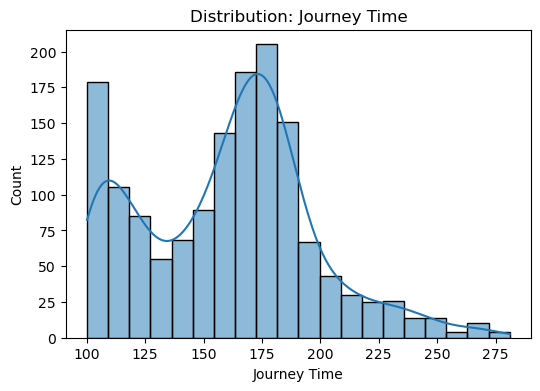

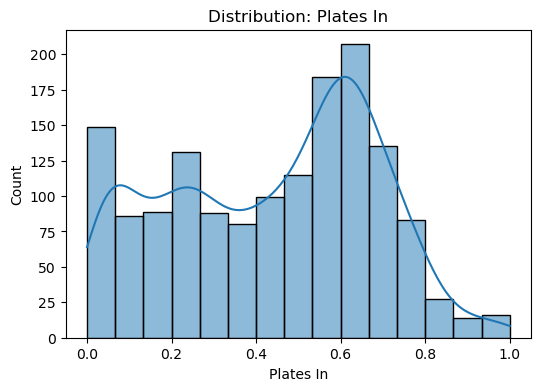

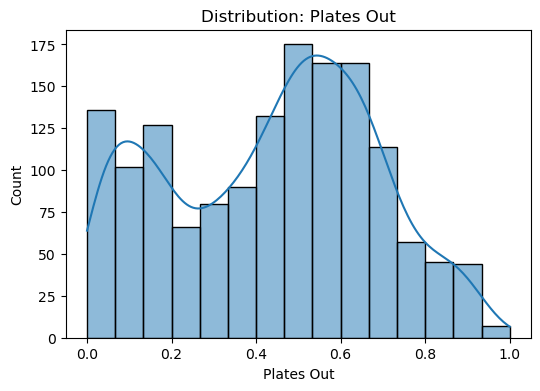

In [59]:
def explore_data(df):
    print("\nBasic Info:\n")
    print(df.info())

    print("\nMissing Values:\n")
    print(df.isna().sum().sort_values(ascending=False))

    print("\nStatistical Summary:\n")
    print(df.describe())

    # Plot distribution of key variables
    to_plot = ["Journey Time", "Plates In", "Plates Out", "PM2.5", "NO2", "Temperature"]
    for col in to_plot:
        if col in df.columns:
            plt.figure(figsize=(6,4))
            sns.histplot(df[col], kde=True)
            plt.title(f"Distribution: {col}")
            plt.show()

explore_data(normalise_df)

In [60]:

dropna = normalise_df.dropna()

display(HTML(dropna.head(10).to_html()))


Variable,hour,day,weekday,month,year,Journey Time,Plates In,Plates Matching,Plates Out,Is Rush Hour,Is Weekend
0,0,1,0,9,2025,118.500000,0.066217,0.076433,0.098985,0,0
1,0,1,5,11,2025,121.200000,0.191902,0.259554,0.225381,0,1
2,0,2,1,9,2025,108.566667,0.051455,0.063694,0.054822,0,0
3,0,3,2,9,2025,106.133333,0.043020,0.060510,0.056853,0,0
4,0,4,1,11,2025,117.133333,0.071278,0.073248,0.072589,0,0
6,0,5,2,11,2025,111.266667,0.111345,0.179936,0.120812,0,0
7,0,5,4,9,2025,111.500000,0.057782,0.078025,0.070051,0,0
8,0,6,5,9,2025,117.933333,0.110924,0.149682,0.149746,0,1
9,0,7,4,11,2025,110.033333,0.093631,0.133758,0.101015,0,0
10,0,7,6,9,2025,124.100000,0.169127,0.202229,0.168020,0,1


In [61]:
# ---------------------------------------------------------
# 2. Final DF
# ---------------------------------------------------------
df = dropna

In [62]:
# ---------------------------------------------------------
# 2. SELECT NUMERIC FEATURES ONLY (XGBoost requirement)
# ---------------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number]).copy()

# Remove label from feature set
X = numeric_df.drop(columns=["Journey Time"])
y = numeric_df["Journey Time"]

display(HTML(numeric_df.head(10).to_html()))


Variable,hour,day,weekday,month,year,Journey Time,Plates In,Plates Matching,Plates Out,Is Rush Hour,Is Weekend
0,0,1,0,9,2025,118.500000,0.066217,0.076433,0.098985,0,0
1,0,1,5,11,2025,121.200000,0.191902,0.259554,0.225381,0,1
2,0,2,1,9,2025,108.566667,0.051455,0.063694,0.054822,0,0
3,0,3,2,9,2025,106.133333,0.043020,0.060510,0.056853,0,0
4,0,4,1,11,2025,117.133333,0.071278,0.073248,0.072589,0,0
6,0,5,2,11,2025,111.266667,0.111345,0.179936,0.120812,0,0
7,0,5,4,9,2025,111.500000,0.057782,0.078025,0.070051,0,0
8,0,6,5,9,2025,117.933333,0.110924,0.149682,0.149746,0,1
9,0,7,4,11,2025,110.033333,0.093631,0.133758,0.101015,0,0
10,0,7,6,9,2025,124.100000,0.169127,0.202229,0.168020,0,1


In [63]:

# ---------------------------------------------------------
# 3. TRAIN/TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False     # IMPORTANT for time-series!!
)

In [64]:

# ---------------------------------------------------------
# 4. XGBoost Model
# ---------------------------------------------------------

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",      # Faster training
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
# ---------------------------------------------------------
# 5. Evaluation
# ---------------------------------------------------------

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("XGBoost Congestion Model Performance:")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

XGBoost Congestion Model Performance:
MAE : 8.860
RMSE: 12.789
R²  : 0.637


In [66]:
for actual, pred in zip(y_test, y_pred):
    print(f"Actual: {actual:.2f}  |  Predicted: {pred:.2f}")

Actual: 164.43  |  Predicted: 174.31
Actual: 169.33  |  Predicted: 175.74
Actual: 150.93  |  Predicted: 156.33
Actual: 159.75  |  Predicted: 178.52
Actual: 160.63  |  Predicted: 153.48
Actual: 163.17  |  Predicted: 162.32
Actual: 151.47  |  Predicted: 151.84
Actual: 157.23  |  Predicted: 160.44
Actual: 172.53  |  Predicted: 154.41
Actual: 154.80  |  Predicted: 158.52
Actual: 163.20  |  Predicted: 155.18
Actual: 153.40  |  Predicted: 164.66
Actual: 149.03  |  Predicted: 152.38
Actual: 175.17  |  Predicted: 163.65
Actual: 180.07  |  Predicted: 176.80
Actual: 170.87  |  Predicted: 162.44
Actual: 175.87  |  Predicted: 167.84
Actual: 171.23  |  Predicted: 172.85
Actual: 150.23  |  Predicted: 142.44
Actual: 151.77  |  Predicted: 159.75
Actual: 165.33  |  Predicted: 157.14
Actual: 170.18  |  Predicted: 167.63
Actual: 143.93  |  Predicted: 153.84
Actual: 162.61  |  Predicted: 162.54
Actual: 172.96  |  Predicted: 169.77
Actual: 137.63  |  Predicted: 136.66
Actual: 176.33  |  Predicted: 161.45
A

In [67]:
# Suppose 'model' is your trained model
with open("my_model.pkl", "wb") as f:
    pickle.dump(model, f)

# To load it later
with open("my_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
